[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/dkaratzas/DL2022-23/blob/main/Problems%207%20-%20Autoencoders/P7_Autoencoders.ipynb)

# Autoencoders

In this notebook we will explore three different types of autoencoder architectures: Simple MLP Autoencoder, Convolutional Autoencoder and Variational Autoencoder (VAE). We will also see how we can use VAEs to generate new data.

In [1]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

# Setting up

In [2]:
#If this cell fails you need to change the runtime of your colab notebook to GPU
# Go to Runtime -> Change Runtime Type and select GPU
assert torch.cuda.is_available(), "GPU is not enabled"

#  use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def show_image(img):
    img = img.clamp(0, 1) # Ensure that the range of greyscales is between 0 and 1
    npimg = img.numpy()   # Convert to NumPy
    npimg = np.transpose(npimg, (2, 1, 0))   # Change the order to (W, H, C)
    plt.imshow(npimg)
    plt.show()

In [4]:
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(
    root="data", train=True, transform=transform, download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="data", train=False, transform=transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True, num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, shuffle=False, num_workers=2
)

100%|██████████| 9912422/9912422 [00:00<00:00, 237179741.48it/s]

Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 32097428.15it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 156631140.93it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 4275253.31it/s]


Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



# Simple Autoencoder

We will define a simple MLP Autoencoder

In [5]:
class AE(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_features=input_size, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=128),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(in_features=128, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=input_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [6]:
model = AE(input_size=784).to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# mean-squared error loss
criterion = nn.MSELoss()

Define the training and testing loops

In [7]:
def train(model, loader, optimizer, criterion, reshape=False):
    loss = 0
    model.train()

    for batch_features, _ in loader:
        # load it to the active device
        batch_features = batch_features.to(device)

        # reshape mini-batch data to [N, 784] matrix (turn images into vectors, and subsume channel)
        if reshape:
            batch_features = batch_features.view(-1, 784)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions
        outputs = model(batch_features)

        # compute training reconstruction loss
        train_loss = criterion(outputs, batch_features)

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(loader)
    print("epoch : {}/{}, Train loss = {:.6f}".format(epoch + 1, epochs, loss))

def test(model, loader, criterion, reshape=False):
    loss = 0
    model.eval()

    for batch_features, _ in loader:
        batch_features = batch_features.to(device)

        # reshape mini-batch data to [N, 784] matrix (turn images into vectors, and subsume channel)
        if reshape:
            batch_features = batch_features.view(-1, 784)

        with torch.no_grad():
            outputs = model(batch_features)

        # compute training reconstruction loss
        test_loss = criterion(outputs, batch_features)

        # add the mini-batch training loss to epoch loss
        loss += test_loss.item()

    # compute the epoch test loss
    loss = loss / len(loader)

    # display the epoch training loss
    print("epoch : {}/{}, Test loss = {:.6f}".format(epoch + 1, epochs, loss))
    show_image(make_grid(batch_features.detach().cpu().view(-1, 1, 28, 28).transpose(2, 3), nrow=2, normalize = True))
    show_image(make_grid(outputs.detach().cpu().view(-1, 1, 28, 28).transpose(2, 3), nrow=2, normalize = True))

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


epoch : 1/10, Train loss = 0.048236
epoch : 1/10, Test loss = 0.024810


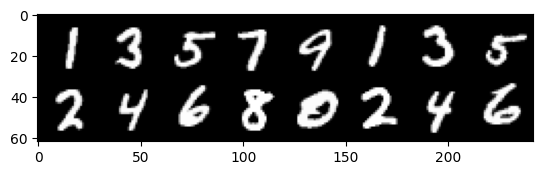

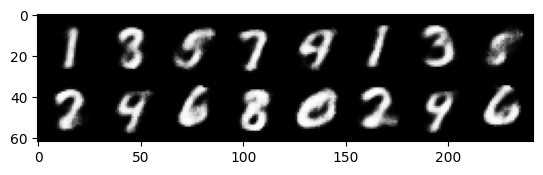

epoch : 2/10, Train loss = 0.020010
epoch : 2/10, Test loss = 0.016081


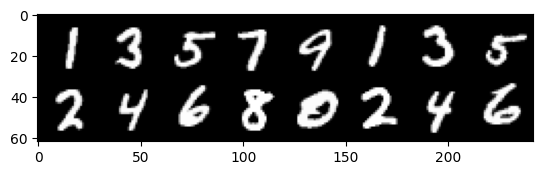

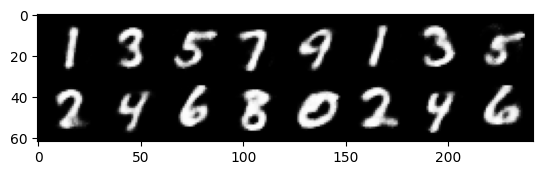

epoch : 3/10, Train loss = 0.014566
epoch : 3/10, Test loss = 0.012645


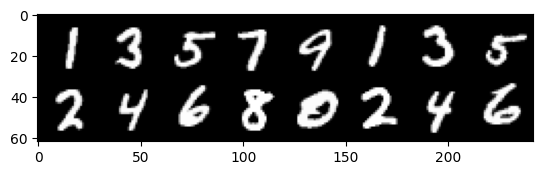

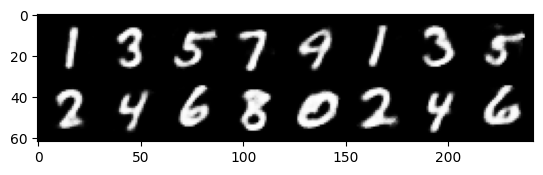

epoch : 4/10, Train loss = 0.012028
epoch : 4/10, Test loss = 0.010767


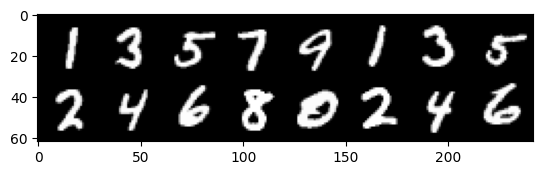

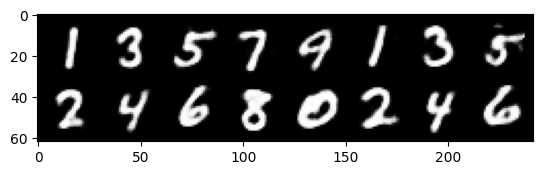

epoch : 5/10, Train loss = 0.010394
epoch : 5/10, Test loss = 0.009523


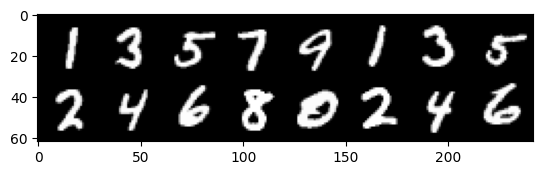

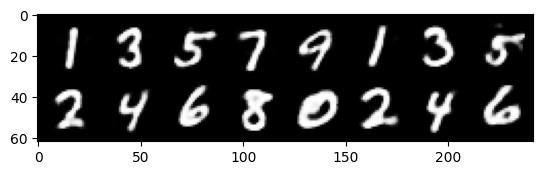

epoch : 6/10, Train loss = 0.009226
epoch : 6/10, Test loss = 0.008464


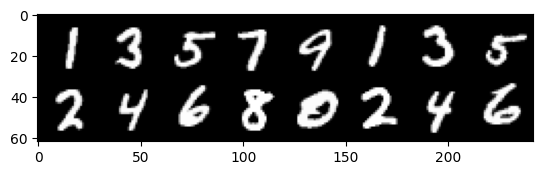

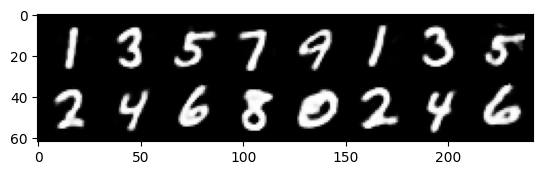

epoch : 7/10, Train loss = 0.008437
epoch : 7/10, Test loss = 0.007998


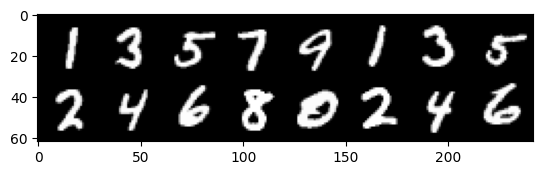

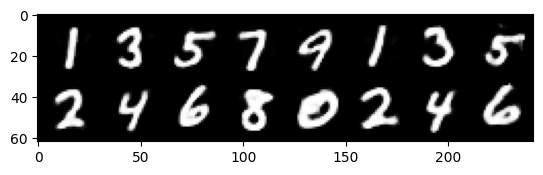

epoch : 8/10, Train loss = 0.007796
epoch : 8/10, Test loss = 0.007308


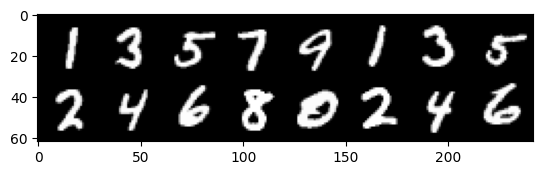

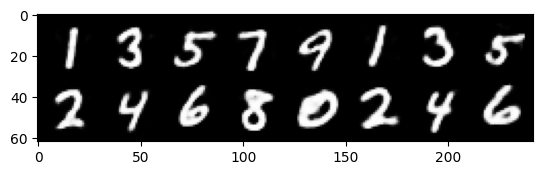

epoch : 9/10, Train loss = 0.007213
epoch : 9/10, Test loss = 0.006750


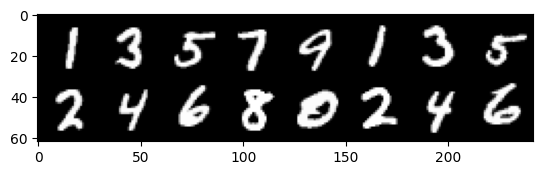

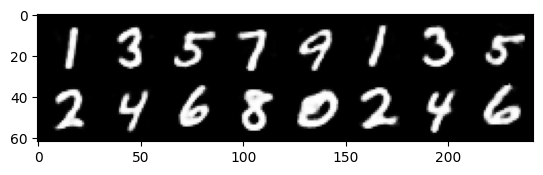

epoch : 10/10, Train loss = 0.006762
epoch : 10/10, Test loss = 0.006430


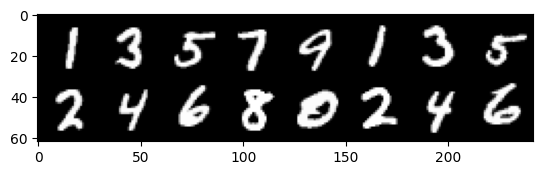

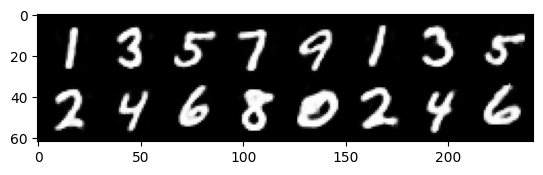

In [8]:
epochs=10
for epoch in range(epochs):
    train(model, train_loader, optimizer, criterion, reshape=True)
    test(model, test_loader, criterion, reshape=True)

# Convolutional Autoencoder

We will now build a convolutional Autoencoder. Below you can find an incomplete implementation of one (only the encoder part)...

In [9]:
class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),  # b, 16, 5, 5
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU(),
            nn.MaxPool2d(2, stride=1)  # b, 8, 2, 2
        )
        self.decoder = nn.Sequential(

            # THIS PART IS MISSING...

        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

<span style="color:blue">

**Exercise 1**: Build the decoder for the convolutional autoencoder model above and train it using the same functions and hyper-parameters as defined above.

> Hint: Use only deconvolutions (design an non-symmetric architecture) so that you do not have to store indices for the unpooling layers. Have a look at `ConvTranspose2d()` https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html

    
> Hint: Remember that to calculate the new activation map's size while deconvolving you should use: $𝑛^{[𝑙]} =(𝑛^{[𝑙−1]}−1) 𝑠 − 2𝑝 + 𝑓$
    
</span>

In [64]:
class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),  # b, 16, 5, 5
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU(),
            nn.MaxPool2d(2, stride=1)  # b, 8, 2, 2
        )
        self.decoder = nn.Sequential(        # b, 8, 2, 2
            nn.ConvTranspose2d(8, 8, 3, stride=2), # b, 8, 4, 4
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 16, 5, stride=2), # b, 16, 13, 13
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=1), # b, 8, 15, 15
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 2, stride=2, padding=1), # b, 1, 28, 28
            nn.Sigmoid()

        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

epoch : 1/10, Train loss = 0.119546
epoch : 1/10, Test loss = 0.114011


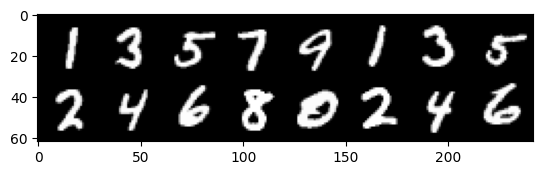

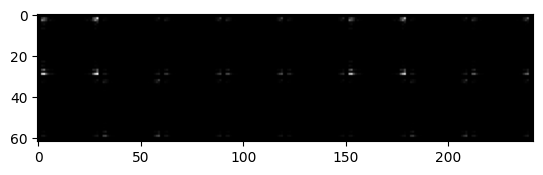

epoch : 2/10, Train loss = 0.112001
epoch : 2/10, Test loss = 0.114009


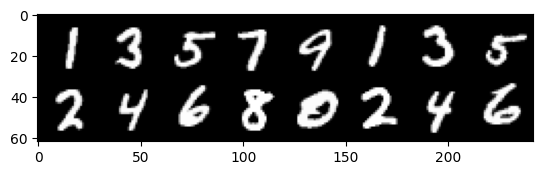

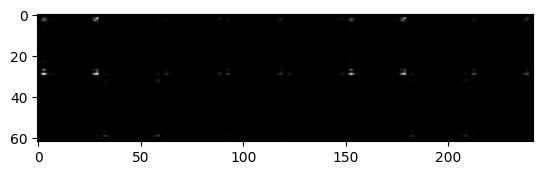

epoch : 3/10, Train loss = 0.112006
epoch : 3/10, Test loss = 0.114008


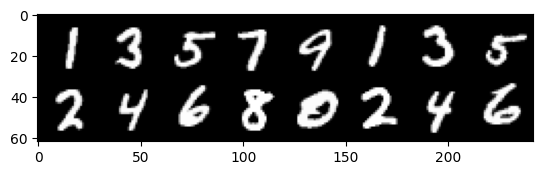

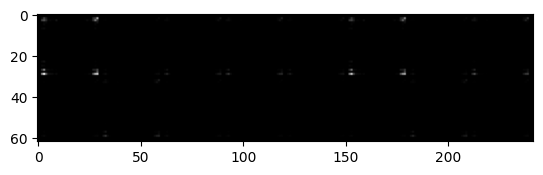

epoch : 4/10, Train loss = 0.112002
epoch : 4/10, Test loss = 0.114008


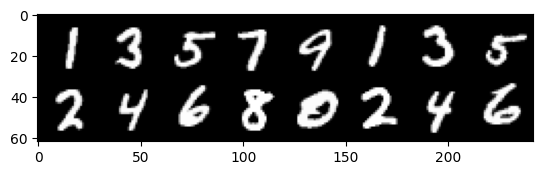

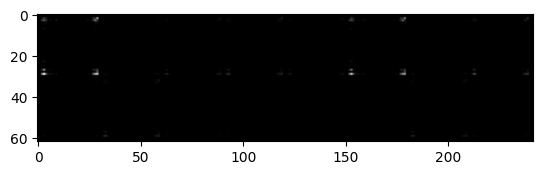

epoch : 5/10, Train loss = 0.112000
epoch : 5/10, Test loss = 0.114008


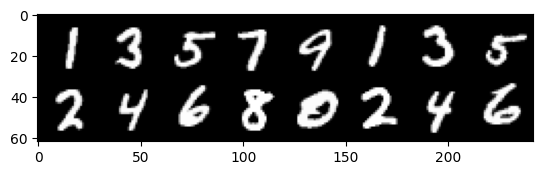

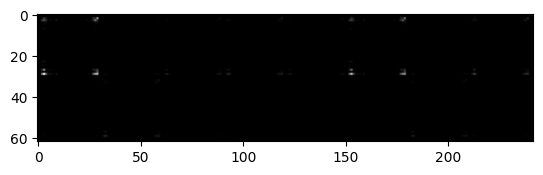

epoch : 6/10, Train loss = 0.112004
epoch : 6/10, Test loss = 0.114008


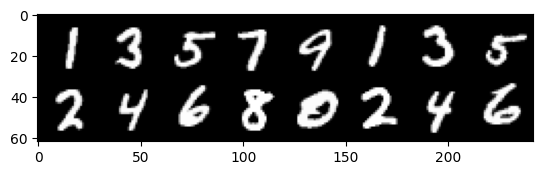

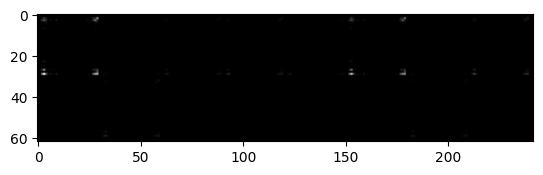

epoch : 7/10, Train loss = 0.112003
epoch : 7/10, Test loss = 0.114008


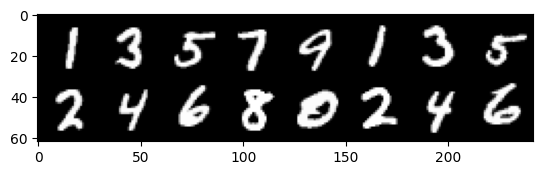

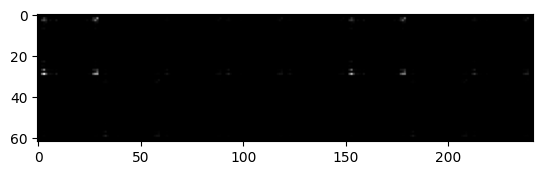

epoch : 8/10, Train loss = 0.112002
epoch : 8/10, Test loss = 0.114008


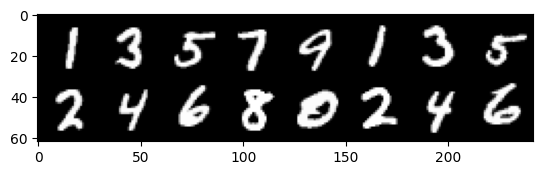

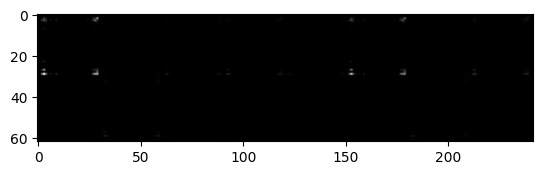

epoch : 9/10, Train loss = 0.112002
epoch : 9/10, Test loss = 0.114008


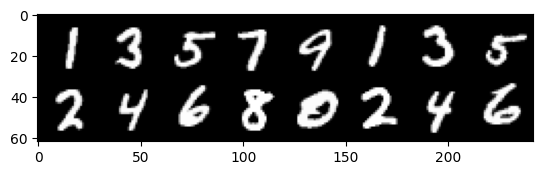

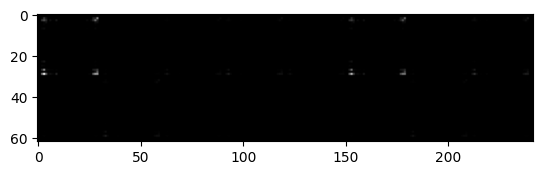

epoch : 10/10, Train loss = 0.112005
epoch : 10/10, Test loss = 0.114008


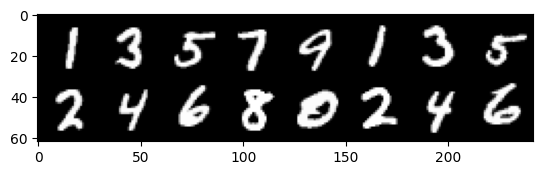

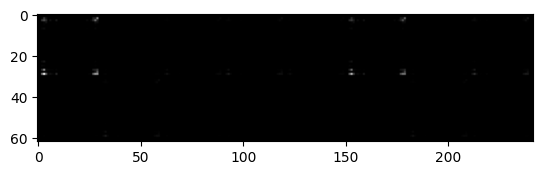

In [65]:
model = ConvAE().to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# mean-squared error loss
criterion = nn.MSELoss()

epochs=10
for epoch in range(epochs):
    train(model, train_loader, optimizer, criterion, reshape=False)
    test(model, test_loader, criterion, reshape=False)

<span style="color:blue">

**Exercise 2 (HOMEWORK)**: Rebuild the network, but this time do a symmetric design for the decoder (using unpooling as required) and train it using the same functions and hyper-parameters as defined above.

> Hint: Have a look at `MaxUnpool2d()` https://pytorch.org/docs/stable/generated/torch.nn.MaxUnpool2d.html
    
</span>

In [66]:
class ConvAE(nn.Module):
    def __init__(self):
        super(ConvAE, self).__init__()
        self.encoder1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=3, padding=1),  # b, 16, 10, 10
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2, stride=2, return_indices=True)  # b, 16, 5, 5
        self.encoder2 = nn.Sequential(
            nn.Conv2d(16, 8, 3, stride=2, padding=1),  # b, 8, 3, 3
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2, stride=1, return_indices=True)  # b, 8, 2, 2

        self.unpool2 = nn.MaxUnpool2d(2, stride=1)     # b, 8, 3, 3
        self.decoder2 = nn.Sequential(
            nn.ReLU(),                       # b, 8, 3, 3
            nn.ConvTranspose2d(8, 16, 3, stride=2, padding=1) # b, 16, 5, 5
        )
        self.unpool1 = nn.MaxUnpool2d(2, stride=2)  # b, 16, 10, 10
        self.decoder1 = nn.Sequential(
            nn.ReLU(),                    # b, 16, 10, 10
            nn.ConvTranspose2d(16, 1, 3, stride=3, padding=1), # b, 1, 28, 28
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder1(x)
        x, indices1 = self.pool1(x)
        x = self.encoder2(x)
        x, indices2 = self.pool2(x)

        x = self.unpool2(x, indices2)
        x = self.decoder2(x)
        x = self.unpool1(x, indices1)
        x = self.decoder1(x)
        return x

epoch : 1/10, Train loss = 0.170652
epoch : 1/10, Test loss = 0.124403


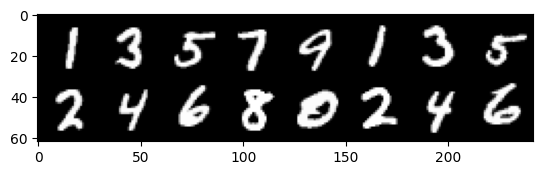

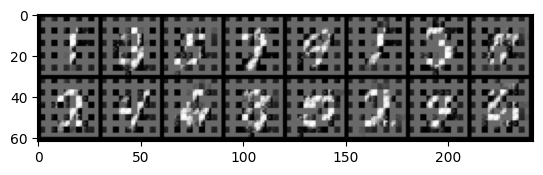

epoch : 2/10, Train loss = 0.104212
epoch : 2/10, Test loss = 0.088014


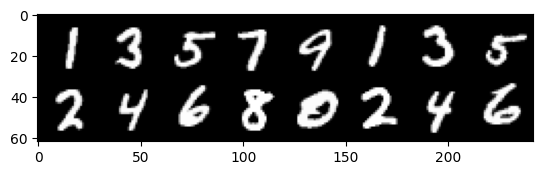

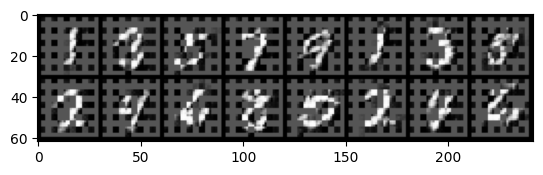

epoch : 3/10, Train loss = 0.076596
epoch : 3/10, Test loss = 0.067194


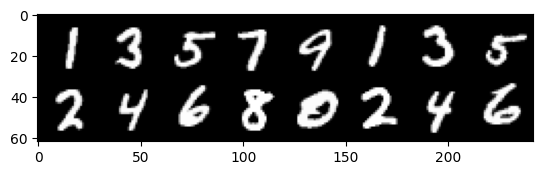

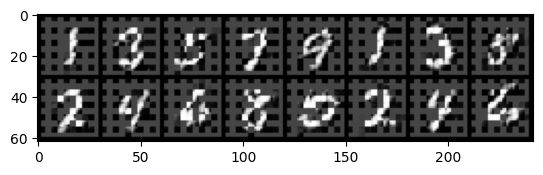

epoch : 4/10, Train loss = 0.059863
epoch : 4/10, Test loss = 0.053565


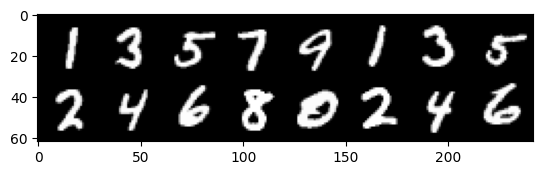

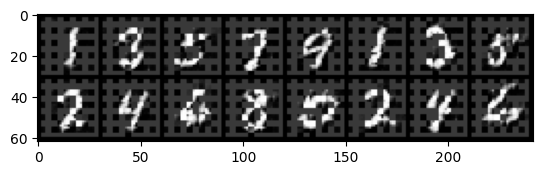

epoch : 5/10, Train loss = 0.048773
epoch : 5/10, Test loss = 0.044793


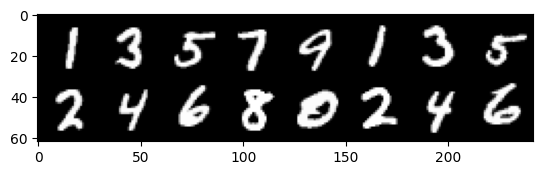

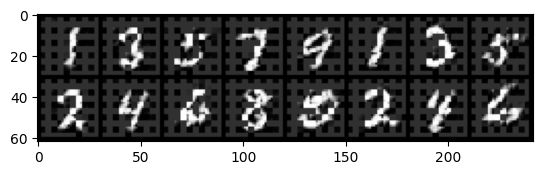

epoch : 6/10, Train loss = 0.041481
epoch : 6/10, Test loss = 0.038884


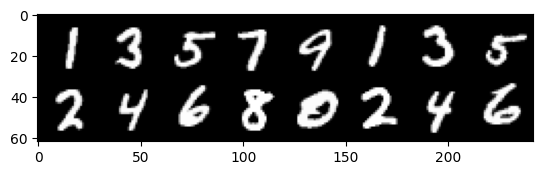

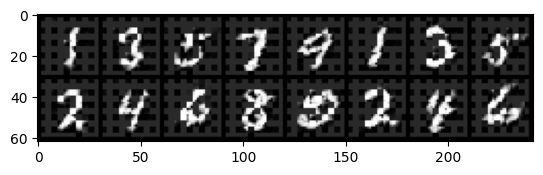

epoch : 7/10, Train loss = 0.036634
epoch : 7/10, Test loss = 0.034876


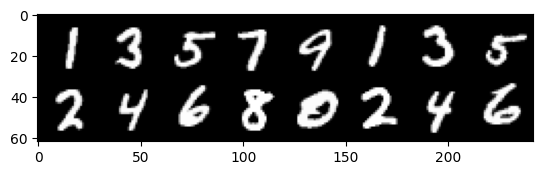

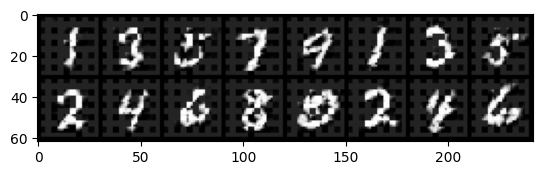

epoch : 8/10, Train loss = 0.033284
epoch : 8/10, Test loss = 0.032060


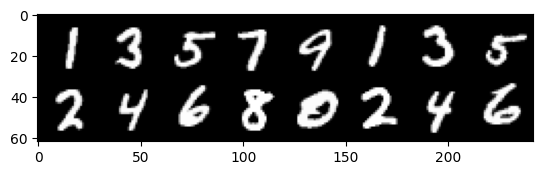

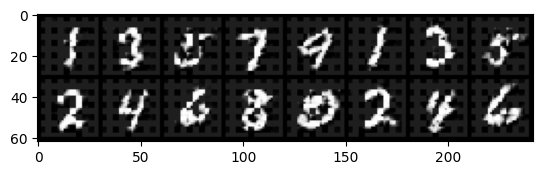

epoch : 9/10, Train loss = 0.030481
epoch : 9/10, Test loss = 0.029057


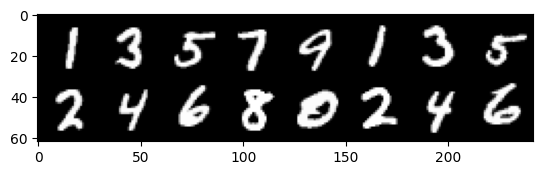

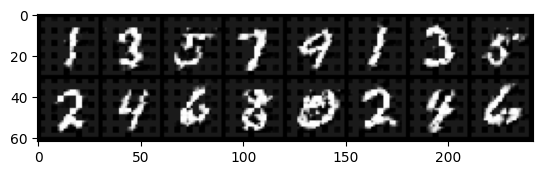

epoch : 10/10, Train loss = 0.027692
epoch : 10/10, Test loss = 0.026679


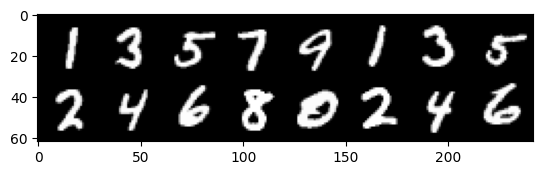

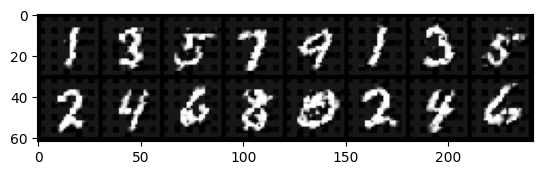

In [67]:
model = ConvAE().to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# mean-squared error loss
criterion = nn.MSELoss()

epochs=10
for epoch in range(epochs):
    train(model, train_loader, optimizer, criterion, reshape=False)
    test(model, test_loader, criterion, reshape=False)

Here, we can see that a grid appears. This is certainly dur to the unpool function, which reconstruct partially the image, giving 0's in the undertermined pixels.

# Variational Autoencoders (VAEs)

Below we define a variational autoencoder. It takes a vector of 784 elements, and maps it into a mean and a `logvar` of size 20.

Note that `logvar` corresponds to $ln(\sigma^2)$.

In [29]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)

        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        if torch.cuda.is_available():
            eps = torch.cuda.FloatTensor(std.size()).normal_()
        else:
            eps = torch.FloatTensor(std.size()).normal_()
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

In the case of the VAE, we need to define our own loss function, as we need to combine the reconstruction loss, with the regularisation term (Gaussian prior for the embedding distribution).

> *NOTE: You will see that we use an MSE loss as a reconstruction loss, instead of the negative log likelihood that we should be using... this actually makes sense. We have designed this model so that the output of the decoder is the image - the pixel values (means) and not distributions over the pixel values (e.g. means and variances of a Gaussian).*

> *This is typical in VAE implementations; the output of the decoder is actually the mean $\mu_{x|z}$ (let's just call it $\mu$) and we usually assumes a unitary covariance. So in that case we have: $log(P(x|z))=-{\frac 1 2}[log(|Σ|)+k log(2\pi)+(x−\mu)^T(x−\mu)]$*

> *This comes from taking the log of the probability density function of a multivariate Gaussian distribution. Now you can see that since the first two terms are constant with respect to $\mu$, the optimization problem is equivalent to maximizing $-{\frac 1 2}(x−\mu)^T(x−\mu)$ which is the just the L2 loss between $x$ and $\mu$. Finally the expectation is just approximated by averaging.*

In [30]:
def loss_function(recon_x, x, mu, logvar):
    """
    recon_x: generating images
    x: origin images
    mu: latent mean
    logvar: latent log variance
    """
    # Reconstruction term
    recLoss = nn.MSELoss(reduction='sum')

    # KL divergence regularisation term
    # loss = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recLoss(recon_x, x) + KLD

In [31]:
#  use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = loss_function

In [32]:
def train_vae(model, loader, optimizer, criterion):
    loss = 0
    model.train()

    for batch_features, _ in loader:
        # load it to the active device
        batch_features = batch_features.to(device)

        # reshape mini-batch data to [N, 784] matrix (turn images into vectors, and subsume channel)
        batch_features = batch_features.view(-1, 784)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions as well as the embeddings (we need them for the loss)
        outputs, mu, logvar = model(batch_features)

        # compute training reconstruction loss
        train_loss = criterion(outputs, batch_features, mu, logvar)

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(loader)
    print("epoch : {}/{}, Train loss = {:.6f}".format(epoch + 1, epochs, loss))


def test_vae(model, loader, criterion):
    loss = 0
    model.eval()

    for batch_features, _ in loader:
        batch_features = batch_features.to(device)

        # reshape mini-batch data to [N, 784] matrix (turn images into vectors, and subsume channel)
        batch_features = batch_features.view(-1, 784)

        with torch.no_grad():
            outputs, mu, logvar = model(batch_features)

        # compute training reconstruction loss
        test_loss = criterion(outputs, batch_features, mu, logvar)

        # add the mini-batch training loss to epoch loss
        loss += test_loss.item()

    # compute the epoch test loss
    loss = loss / len(loader)

    # display the epoch training loss
    print("epoch : {}/{}, Test loss = {:.6f}".format(epoch + 1, epochs, loss))
    show_image(make_grid(batch_features.detach().cpu().view(-1, 1, 28, 28).transpose(2, 3), nrow=2, normalize = True))
    show_image(make_grid(outputs.detach().cpu().view(-1, 1, 28, 28).transpose(2, 3), nrow=2, normalize = True))

<ipython-input-29-f0bbe4192b33>:19: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:83.)
  eps = torch.cuda.FloatTensor(std.size()).normal_()


epoch : 1/10, Train loss = 5777.546487
epoch : 1/10, Test loss = 1164.340211


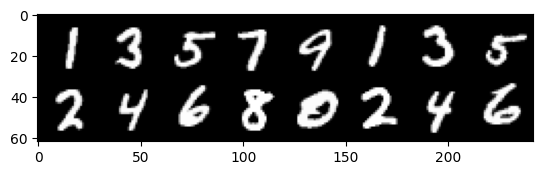

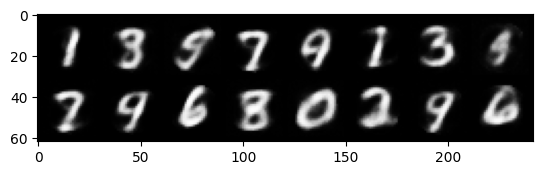

epoch : 2/10, Train loss = 4468.261246
epoch : 2/10, Test loss = 1072.784301


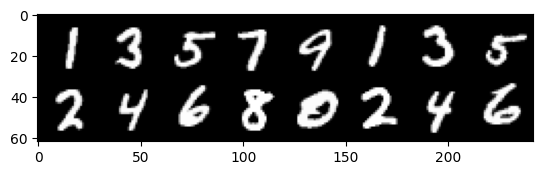

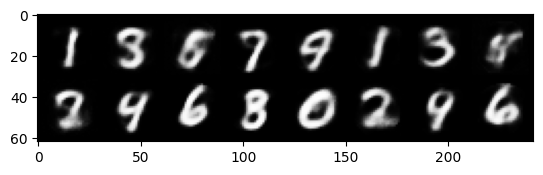

epoch : 3/10, Train loss = 4236.473241
epoch : 3/10, Test loss = 1032.469961


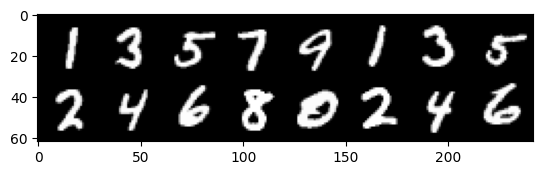

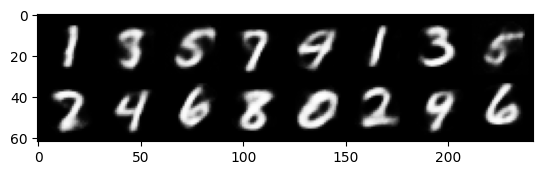

epoch : 4/10, Train loss = 4127.560174
epoch : 4/10, Test loss = 1011.453410


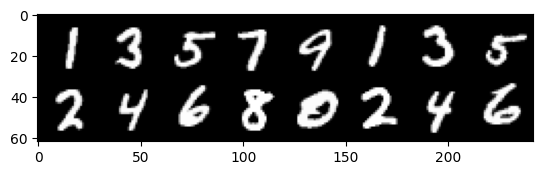

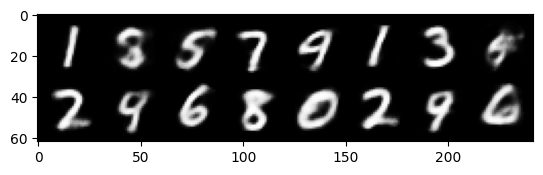

epoch : 5/10, Train loss = 4054.458081
epoch : 5/10, Test loss = 1000.362177


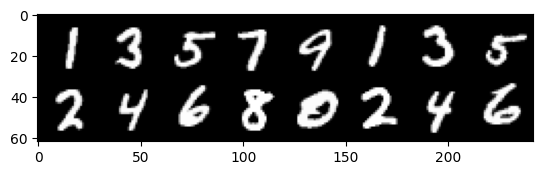

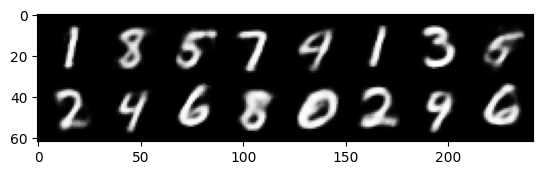

epoch : 6/10, Train loss = 4014.680028
epoch : 6/10, Test loss = 989.084997


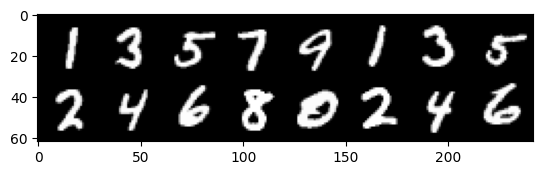

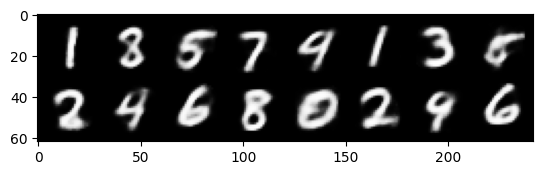

epoch : 7/10, Train loss = 3977.322286
epoch : 7/10, Test loss = 985.921667


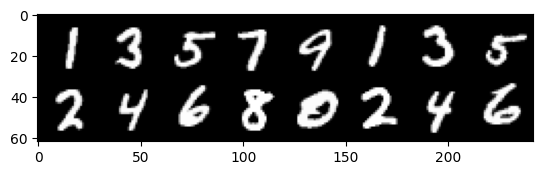

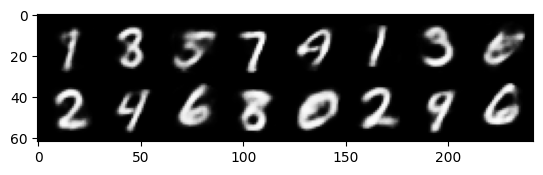

epoch : 8/10, Train loss = 3954.030869
epoch : 8/10, Test loss = 979.672309


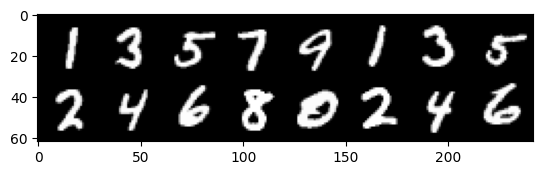

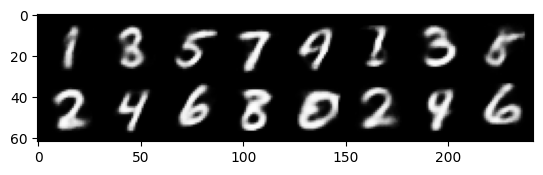

epoch : 9/10, Train loss = 3930.856299
epoch : 9/10, Test loss = 970.326020


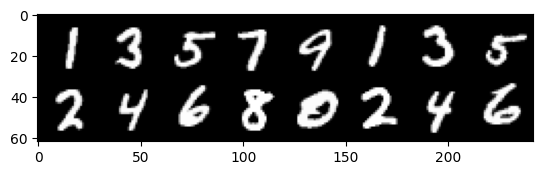

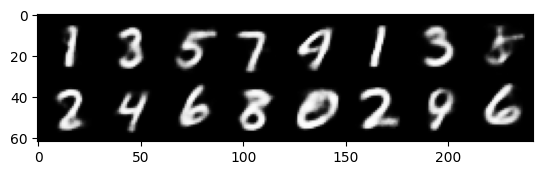

epoch : 10/10, Train loss = 3912.304853
epoch : 10/10, Test loss = 969.303584


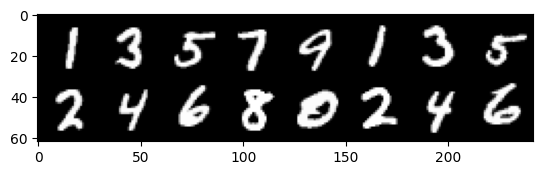

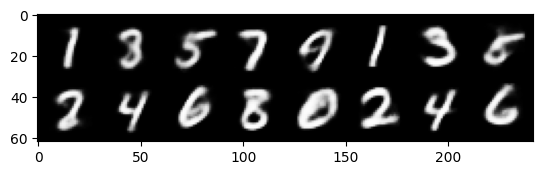

In [33]:
epochs=10
for epoch in range(epochs):
    train_vae(model, train_loader, optimizer, criterion)
    test_vae(model, test_loader, criterion)

We can now use our variational autoencoder to generate new digits. Below we select two digits, and we interpolate between their embeddings to generate embeddings on the line connecting the two original digits. Then we plot them - you should be able to see an evolution from one to the other.

In [34]:
model.eval()

def interpolation(lambda1, model, img1, img2):

    with torch.no_grad():

        # latent vector of first image
        #img1 = img1.view(img1.size(0), -1).to(device)
        img1 = img1.view(-1, 784).to(device)
        latent_1, _ = model.encode(img1)

        # latent vector of second image
        #img2 = img2.view(img2.size(0), -1).to(device)
        img2 = img2.view(-1, 784).to(device)
        latent_2, _ = model.encode(img2)

        # interpolation of the two latent vectors
        inter_latent = (1-lambda1) * latent_1 + lambda1 * latent_2

        # reconstruct interpolated image
        inter_image = model.decode(inter_latent)
        inter_image = inter_image.cpu()

        return inter_image


def visualize_interpolation(model, test_dataloader, digit1 = 7, digit2 = 1):
    # sort part of test set by digit
    digits = [[] for _ in range(10)] # an empty structure to keep samples corresponding to the different digits

    for img_batch, label_batch in test_dataloader:
        for i in range(img_batch.size(0)):
            digits[label_batch[i]].append(img_batch[i:i+1])
        if sum(len(d) for d in digits) >= 1000: # stop when we reach 1000 digits
            break;

    # interpolation lambdas
    lambda_range=np.linspace(0,1,10) # Get 10 points between 0 and 1

    fig, axs = plt.subplots(2,5, figsize=(15, 6))
    fig.subplots_adjust(hspace = .5, wspace=.001)
    axs = axs.ravel()

    for ind,l in enumerate(lambda_range):
        inter_image=interpolation(float(l), model, digits[digit1][0], digits[digit2][0])

        inter_image = inter_image.view(1, 28, 28)

        image = inter_image.numpy()
        axs[ind].imshow(image[0,:,:], cmap='gray')
        axs[ind].set_title('lambda_val='+str(round(l,1)))
    plt.show()

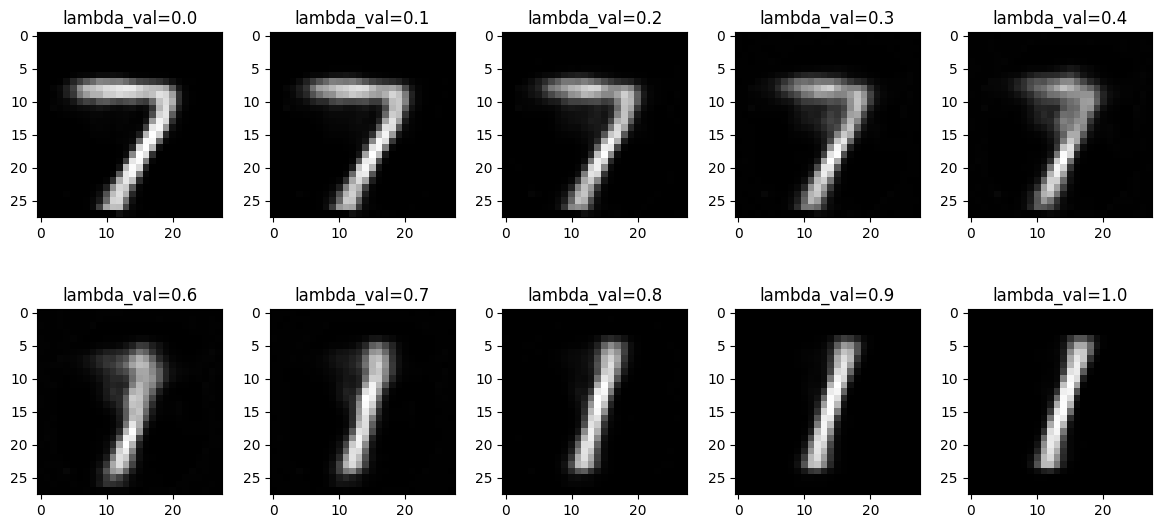

In [35]:
visualize_interpolation(model, test_loader, 7, 1)

<span style="color:blue">

**Exercise 3**: Use the already trained VAE model to generate 100 random new digits.

> Hint: Have a look at PyTorch's `randn()` https://pytorch.org/docs/stable/generated/torch.randn.html
    
</span>

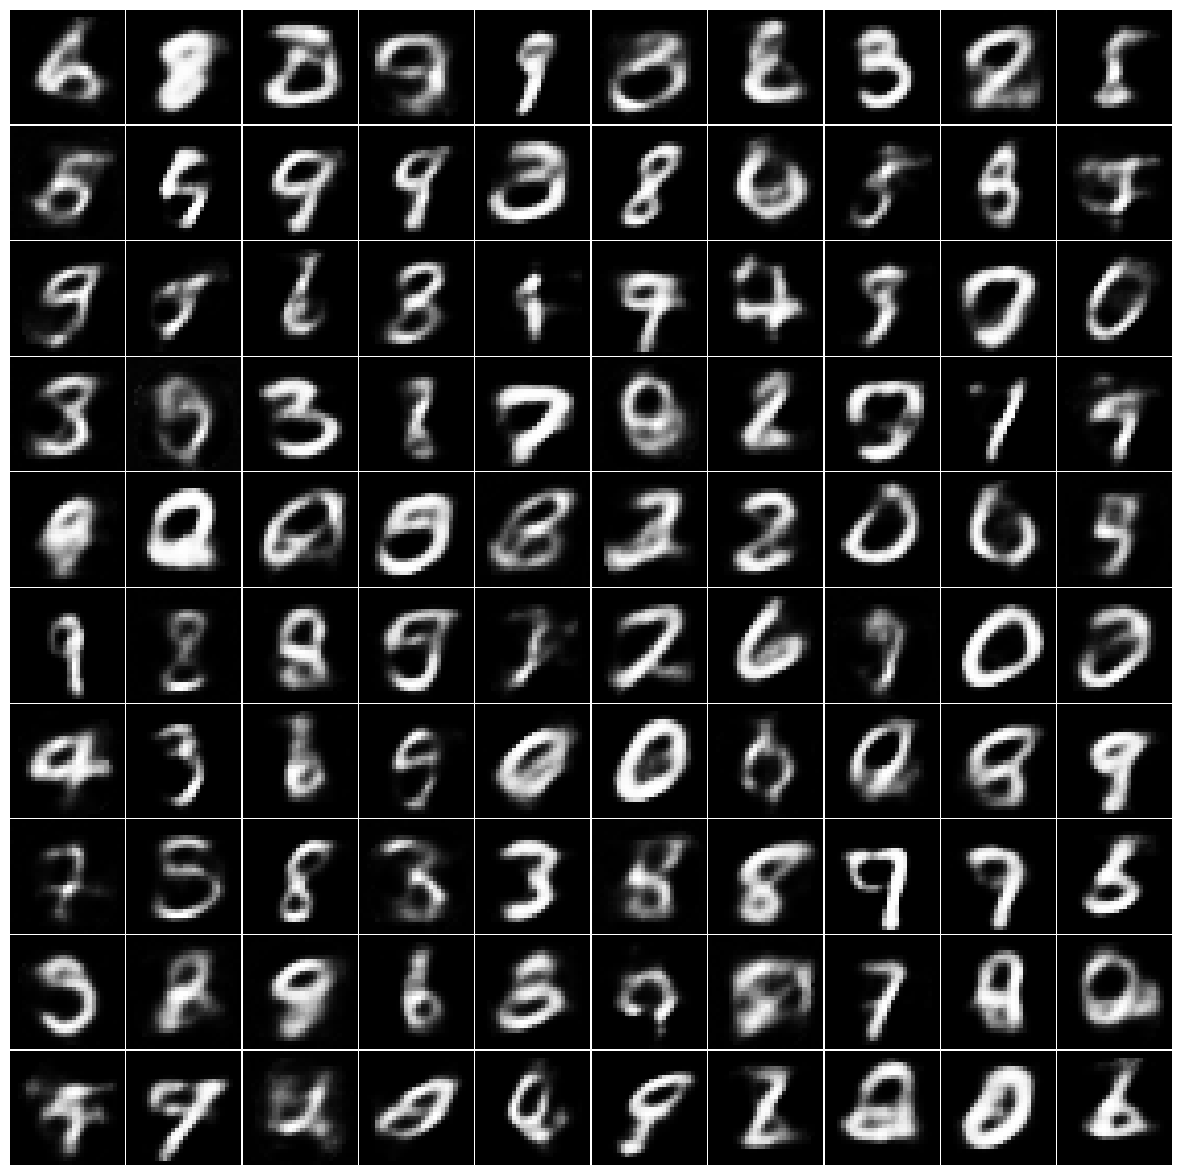

In [36]:
with torch.no_grad():
    # Generate random latent vectors
    latent_samples = torch.randn(100, model.fc21.out_features).to(device)

    # Decode the latent vectors to generate images
    generated_images = model.decode(latent_samples)

    # Plots
    fig, axs = plt.subplots(10, 10, figsize=(15, 15))
    fig.subplots_adjust(hspace=0.01, wspace=0.01)

    for i in range(10):
        for j in range(10):
            img_index = i * 10 + j
            img = generated_images[img_index].cpu()
            img = img.view(1, 28, 28)
            axs[i, j].imshow(img[0,:,:], cmap='gray')
            axs[i, j].axis('off')

plt.show()

<span style="color:blue">

**Exercise 4**: Modify the VAE model so that it creates a 2-dimensional latent space. Train it on MNIST and then complete the cell below to visualize the entire 2D latent space.
    
</span>

In [37]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 2)
        self.fc22 = nn.Linear(400, 2)

        self.fc3 = nn.Linear(2, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        if torch.cuda.is_available():
            eps = torch.cuda.FloatTensor(std.size()).normal_()
        else:
            eps = torch.FloatTensor(std.size()).normal_()
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

epoch : 1/10, Train loss = 6279.323325
epoch : 1/10, Test loss = 1374.238779


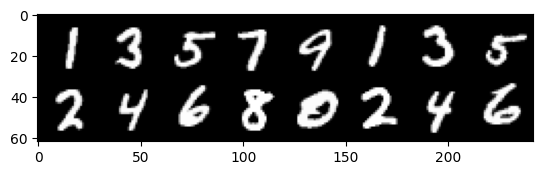

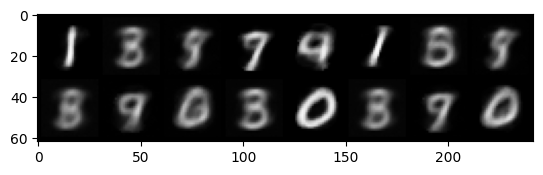

epoch : 2/10, Train loss = 5407.753189
epoch : 2/10, Test loss = 1324.147102


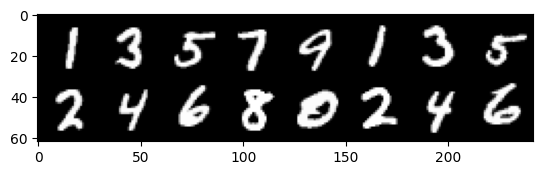

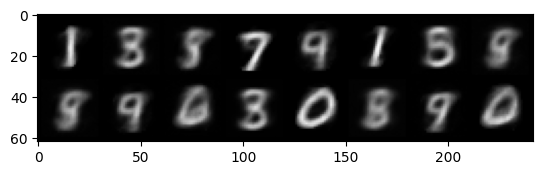

epoch : 3/10, Train loss = 5270.283914
epoch : 3/10, Test loss = 1305.903979


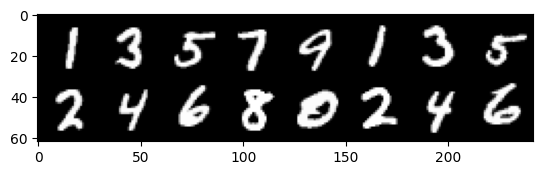

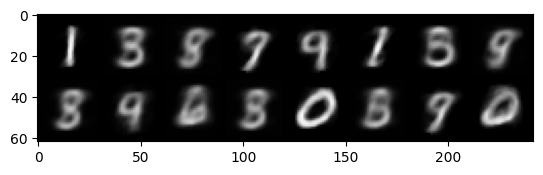

epoch : 4/10, Train loss = 5185.629729
epoch : 4/10, Test loss = 1285.410476


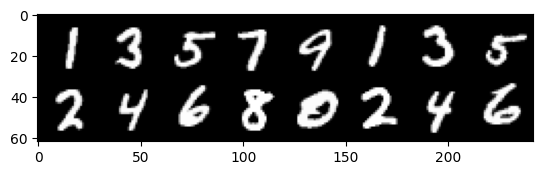

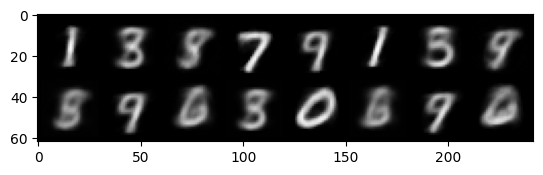

epoch : 5/10, Train loss = 5123.874860
epoch : 5/10, Test loss = 1272.631731


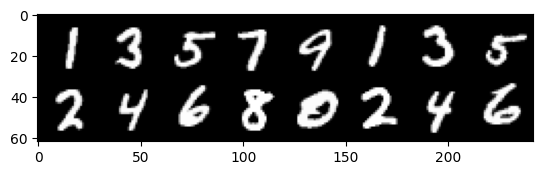

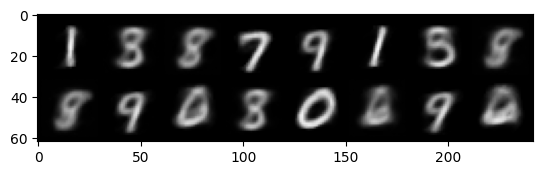

epoch : 6/10, Train loss = 5077.319040
epoch : 6/10, Test loss = 1260.943556


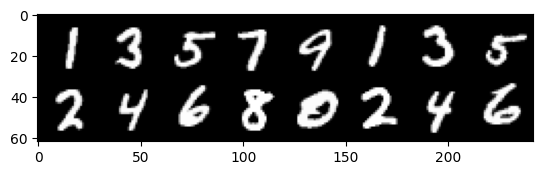

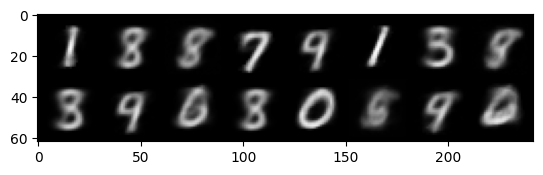

epoch : 7/10, Train loss = 5039.491385
epoch : 7/10, Test loss = 1256.016041


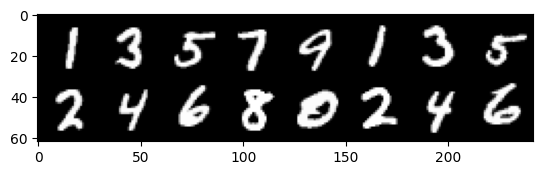

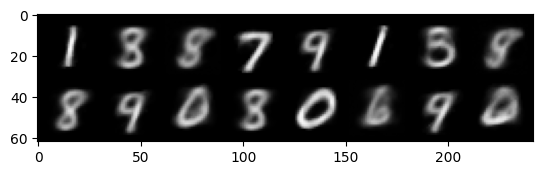

epoch : 8/10, Train loss = 5006.285994
epoch : 8/10, Test loss = 1249.013598


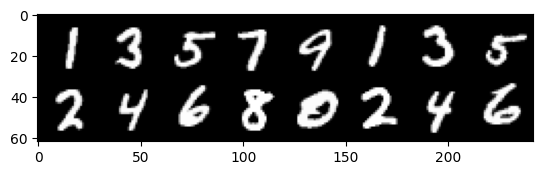

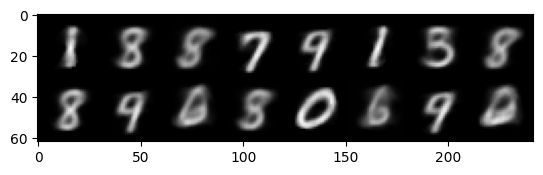

epoch : 9/10, Train loss = 4975.293760
epoch : 9/10, Test loss = 1240.002621


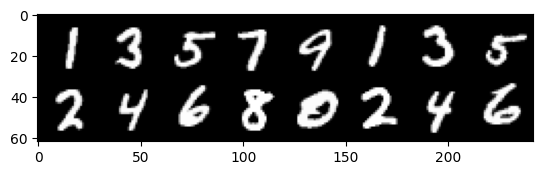

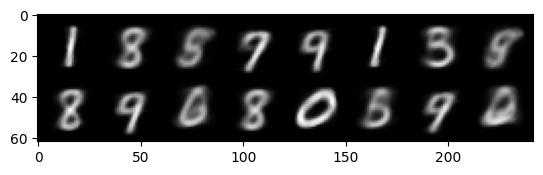

epoch : 10/10, Train loss = 4954.238025
epoch : 10/10, Test loss = 1240.670213


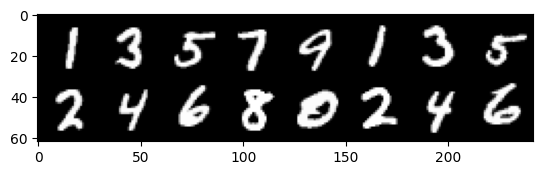

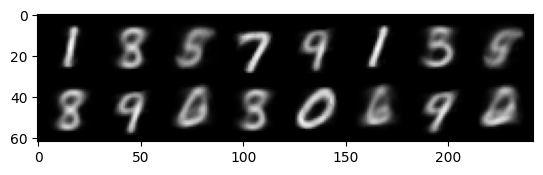

In [38]:
#  use gpu if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = loss_function

epochs=10
for epoch in range(epochs):
    train_vae(model, train_loader, optimizer, criterion)
    test_vae(model, test_loader, criterion)

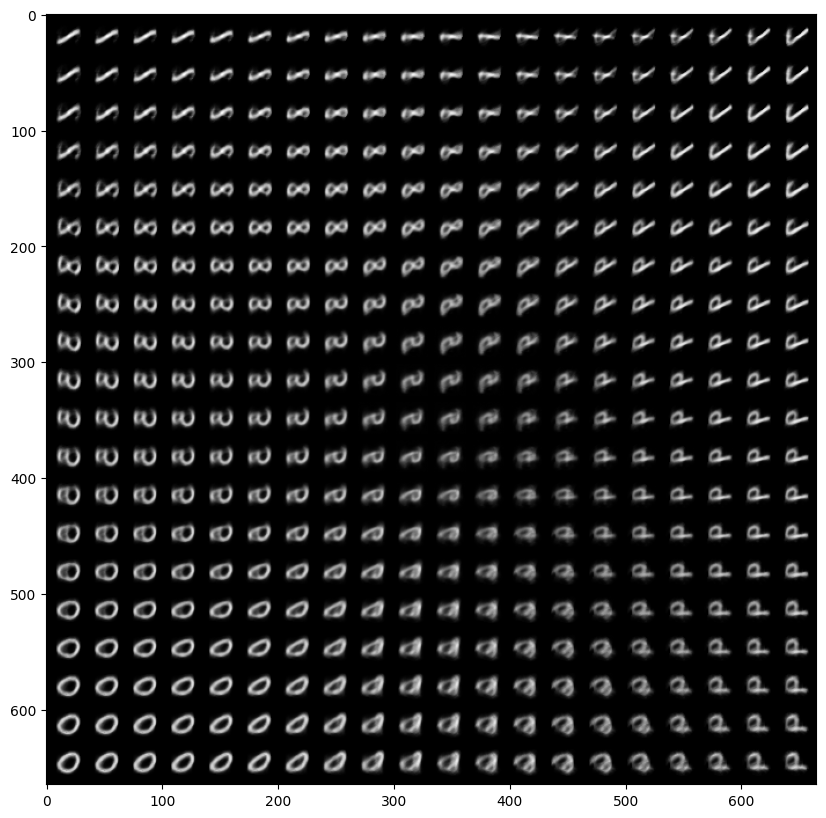

In [39]:
with torch.no_grad():

    # create a sample grid in 2d latent space
    latent_x = np.linspace(-1.5,1.5,20)
    latent_y = np.linspace(-1.5,1.5,20)
    latents = torch.FloatTensor(len(latent_y), len(latent_x), 2).to(device)
    for i, lx in enumerate(latent_x):
        for j, ly in enumerate(latent_y):
            latents[j, i, 0] = lx
            latents[j, i, 1] = ly
    latents = latents.view(-1, 2) # flatten grid into a batch

    # reconstruct images from the latent vectors
    image_recon = model.decode(latents).cpu()


    fig, ax = plt.subplots(figsize=(10, 10))
    show_image(torchvision.utils.make_grid(image_recon.view(-1, 1, 28, 28),20,5))
    plt.show()

# New dataset

<span style="color:blue">

**Exercise 5**: Try both the simple encoder and the convolutional encoder with the FashionMNIST dataset, comment what you observe for both results.
    
</span>

In [40]:
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

train_dataset_FMNIST = torchvision.datasets.FashionMNIST(
    root="data", train=True, transform=transform, download=True
)

test_dataset_FMNIST = torchvision.datasets.FashionMNIST(
    root="data", train=False, transform=transform, download=True
)

train_loader_FMNIST = torch.utils.data.DataLoader(
    train_dataset_FMNIST, batch_size=128, shuffle=True, num_workers=2#, pin_memory=True
)

test_loader_FMNIST = torch.utils.data.DataLoader(
    test_dataset_FMNIST, batch_size=32, shuffle=False, num_workers=2
)

100%|██████████| 26421880/26421880 [00:02<00:00, 9769719.54it/s] 


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 167802.41it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 3134651.71it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 5659836.70it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



epoch : 1/10, Train loss = 0.020860
epoch : 1/10, Test loss = 0.004393


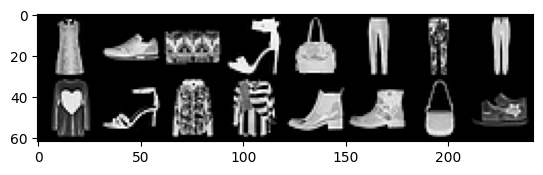

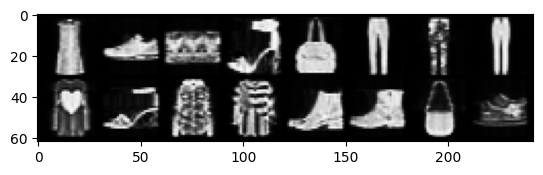

epoch : 2/10, Train loss = 0.003072
epoch : 2/10, Test loss = 0.002090


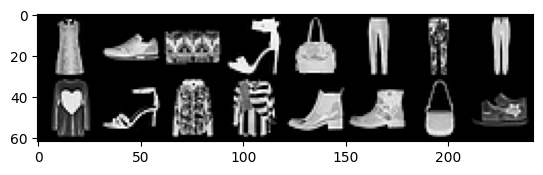

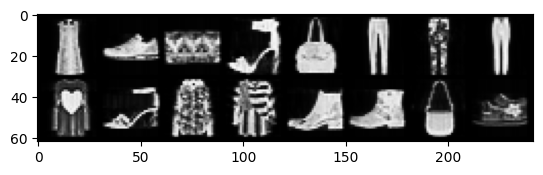

epoch : 3/10, Train loss = 0.001602
epoch : 3/10, Test loss = 0.001272


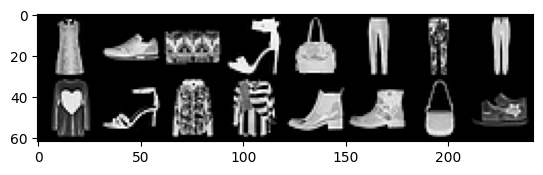

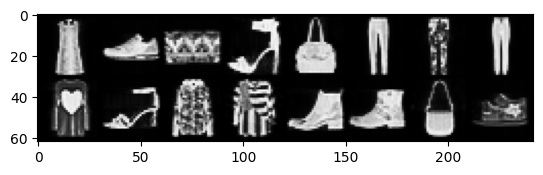

epoch : 4/10, Train loss = 0.001076
epoch : 4/10, Test loss = 0.000910


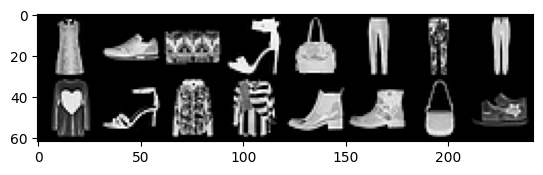

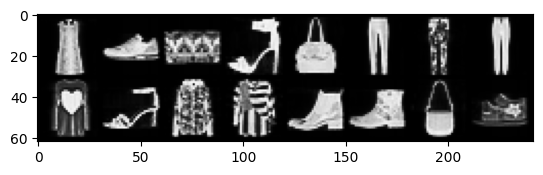

epoch : 5/10, Train loss = 0.000854
epoch : 5/10, Test loss = 0.000819


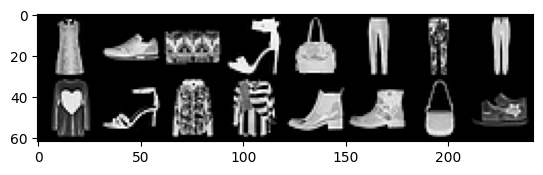

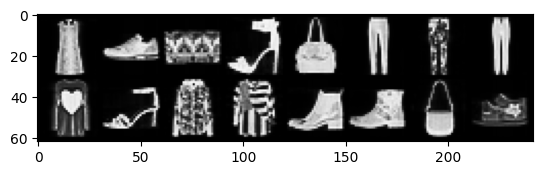

epoch : 6/10, Train loss = 0.000717
epoch : 6/10, Test loss = 0.000650


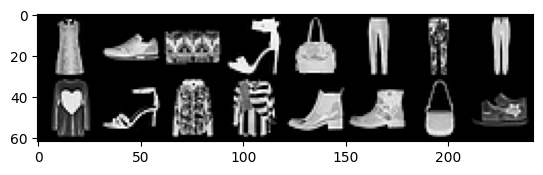

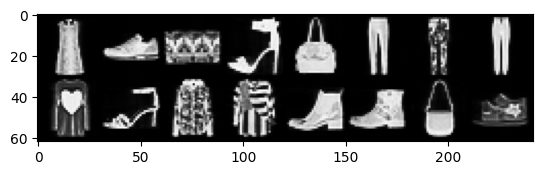

epoch : 7/10, Train loss = 0.000632
epoch : 7/10, Test loss = 0.000593


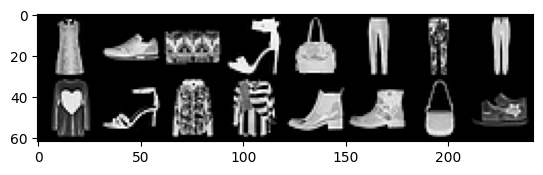

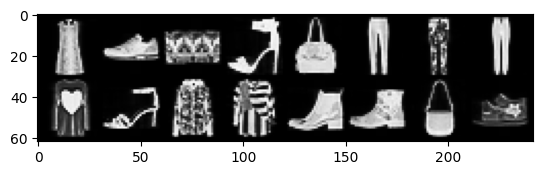

epoch : 8/10, Train loss = 0.000578
epoch : 8/10, Test loss = 0.000549


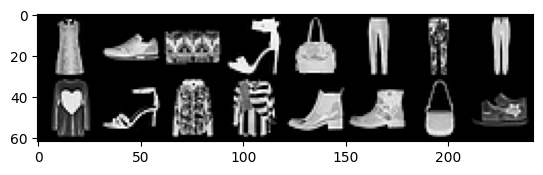

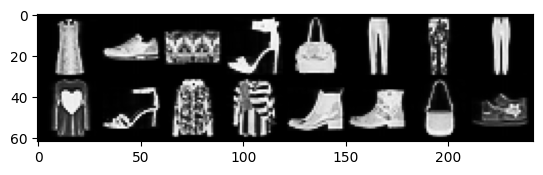

epoch : 9/10, Train loss = 0.000531
epoch : 9/10, Test loss = 0.000490


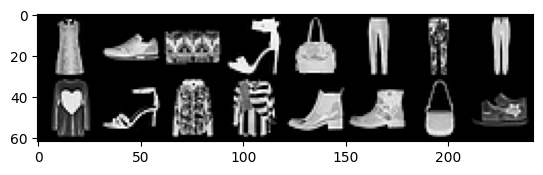

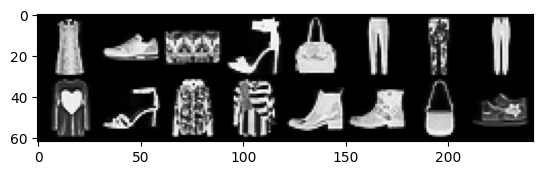

epoch : 10/10, Train loss = 0.000500
epoch : 10/10, Test loss = 0.000521


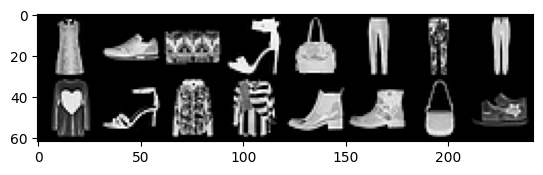

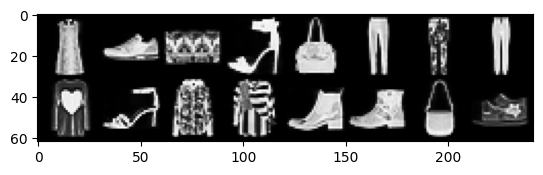

In [41]:
model = AE(input_size=28).to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# mean-squared error loss
criterion = nn.MSELoss()

epochs=10
for epoch in range(epochs):
    train(model, train_loader_FMNIST, optimizer, criterion)
    test(model, test_loader_FMNIST, criterion)

epoch : 1/10, Train loss = 0.116926
epoch : 1/10, Test loss = 0.095784


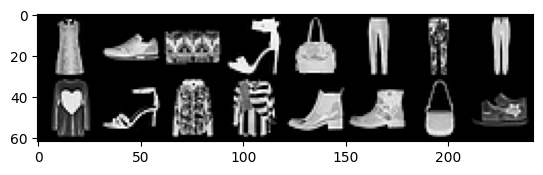

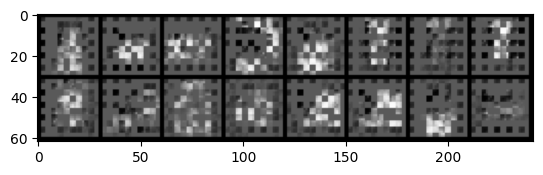

epoch : 2/10, Train loss = 0.087170
epoch : 2/10, Test loss = 0.080414


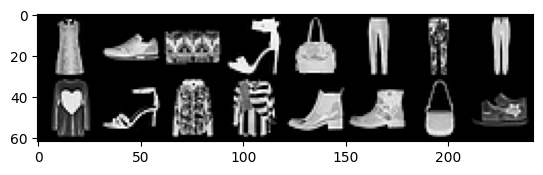

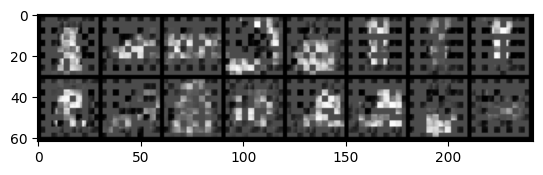

epoch : 3/10, Train loss = 0.076643
epoch : 3/10, Test loss = 0.073675


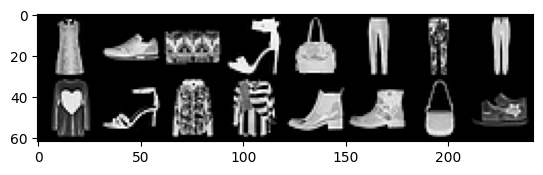

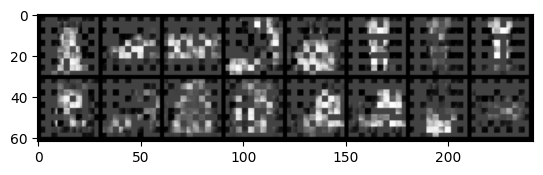

epoch : 4/10, Train loss = 0.072286
epoch : 4/10, Test loss = 0.070918


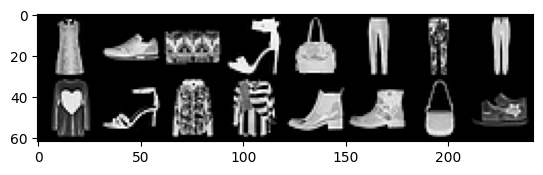

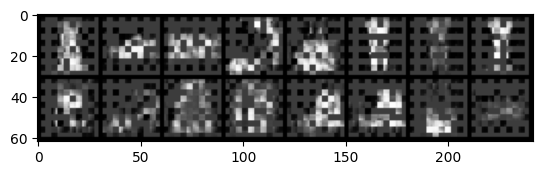

epoch : 5/10, Train loss = 0.070232
epoch : 5/10, Test loss = 0.069340


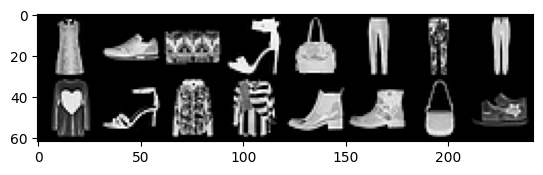

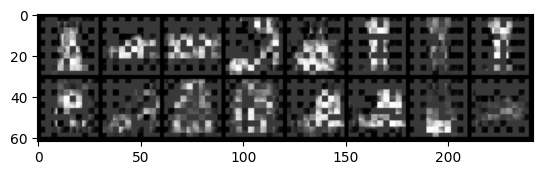

epoch : 6/10, Train loss = 0.068745
epoch : 6/10, Test loss = 0.067936


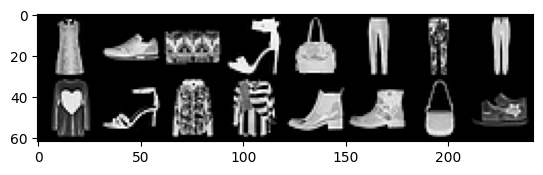

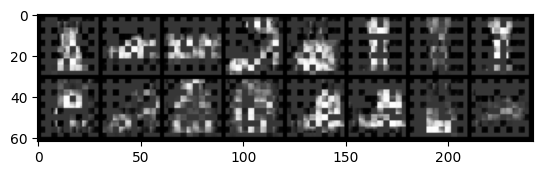

epoch : 7/10, Train loss = 0.067343
epoch : 7/10, Test loss = 0.066587


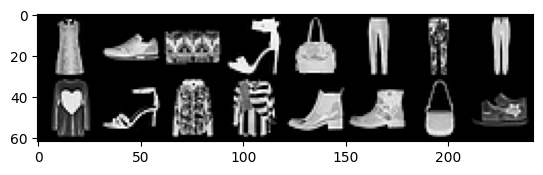

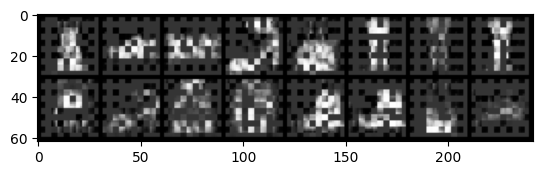

epoch : 8/10, Train loss = 0.065957
epoch : 8/10, Test loss = 0.065138


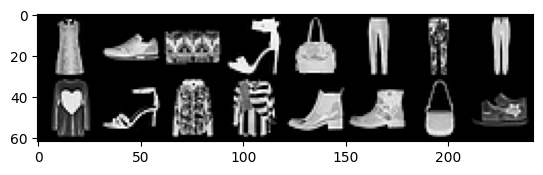

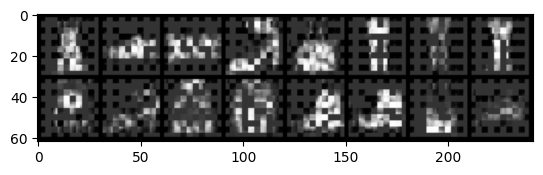

epoch : 9/10, Train loss = 0.064525
epoch : 9/10, Test loss = 0.063579


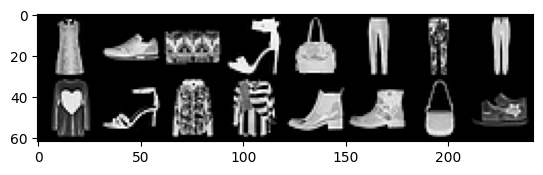

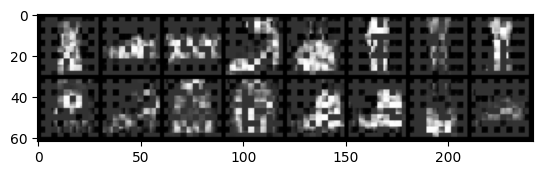

epoch : 10/10, Train loss = 0.062850
epoch : 10/10, Test loss = 0.062078


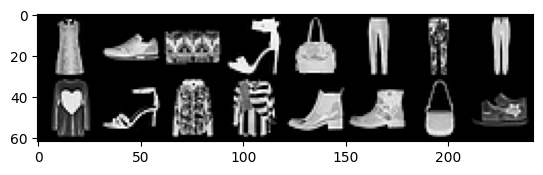

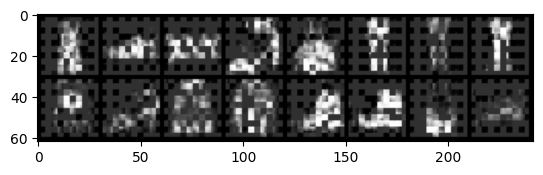

In [68]:
model = ConvAE().to(device)

# create an optimizer object
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# mean-squared error loss
criterion = nn.MSELoss()

epochs=10
for epoch in range(epochs):
    train(model, train_loader_FMNIST, optimizer, criterion)
    test(model, test_loader_FMNIST, criterion)

We can see here that the simple encoder seems to be better in that case. In fact, we can observe that during the last epoch of training, the outputs images are practically equal to the input ones.

On the other hand, the convolutional one seems to be less accurate. As seen with its use before, we can observe a grey grid in the middle of the image, which leads to a more noisy output.